# Intervalles de confiance et régions de prédiction - KMAXPP05

## Configuration du notebook

In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import RocCurveDisplay

In [3]:
import warnings

## Estimation d'un paramètre unique

In [4]:
hommes_dist = sp.stats.norm(177.5, 7.7)        # taille moyenne et écart type des hommes
femmes_dist = sp.stats.norm(164.2, 6.3)        # taille moyenne et écart type des femmes
univ_toulouse_dist = sp.stats.bernoulli(0.54)  # on suppose qu'il y a 54% d'hommes sur le campus parmi les étudiants

In [5]:
def generer_echantillon(n):
    # On génère des étudiants en suivant la loi de Bernoulli
    e = univ_toulouse_dist.rvs(n)
    # On génère un échantillon de tailles pour les hommes grâce à une loi normale
    hommes_tailles = hommes_dist.rvs(e.sum())
    # On génère un échantillon de tailles pour les femmes grâce à une loi normale
    femmes_tailles = femmes_dist.rvs(n - e.sum())
    # On combine les deux échantillons
    tailles = np.hstack((hommes_tailles, femmes_tailles))
    return tailles

In [6]:
def tracer_intervalle(array, option="prediction"):
    if option == "prediction":
        label1 = "Données"
        label2 = "Intervalle de prédiction 95%"
        title = "Intervalle de prédiction"
    else:
        label1 = "Moyennes des échantillons"
        label2 = "Intervalle de confiance 95%"
        title = "Intervalle de confiance"    
    # Estimateur maximal de vraisemblance
    mu, sigma = sp.stats.norm.fit(array)
    norm = sp.stats.norm(mu, sigma)  
    # Tracé des données
    plt.scatter(array, np.zeros_like(array), marker="|", s=200, label=label1)
    # Tracé de l'incertitude
    x = np.linspace(-4., 4., 1000)
    plt.plot(x * sigma + mu, norm.pdf(x * sigma + mu), label="EMV")
    q0025, q0975 = norm.ppf([0.025, 0.975])
    cond = ((x * sigma + mu) >= q0025) & ((x * sigma + mu) <= q0975)
    plt.fill_between(x * sigma + mu, norm.pdf(x * sigma + mu), where=cond, alpha=0.25, label=label2)
    # Options cosmétiques
    plt.ylim(0., None)
    plt.xlim(140., 200.)
    plt.xlabel("Taille [cm]")
    plt.ylabel("Densité de probabilité")
    plt.title(title, pad=30)
    plt.legend(loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=True)
    plt.tight_layout()

In [7]:
def calculer_moyennes(n, m):
    # Calcul des moyennes avec une simulation de Monte Carlo
    # n: taille de l'échantillon
    # m: nombre de simulations
    mean_arr = []
    for i in range(m):
        tailles = generer_echantillon(n)
        mean = tailles.mean()
        mean_arr.append(mean)
    mean_arr = np.array(mean_arr)    
    return mean_arr

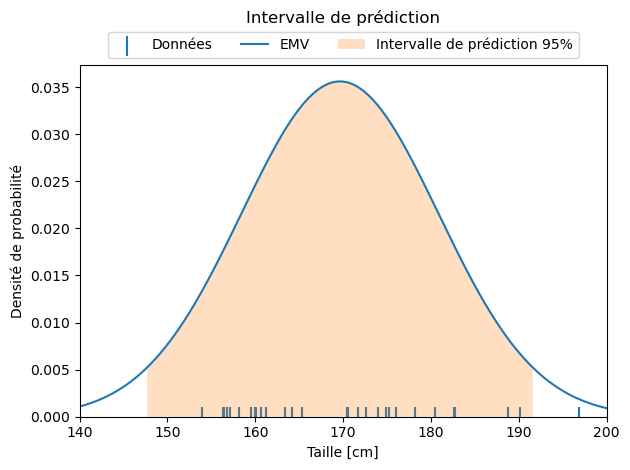

In [8]:
n = 30
tailles = generer_echantillon(n)
tracer_intervalle(tailles, option="prediction")

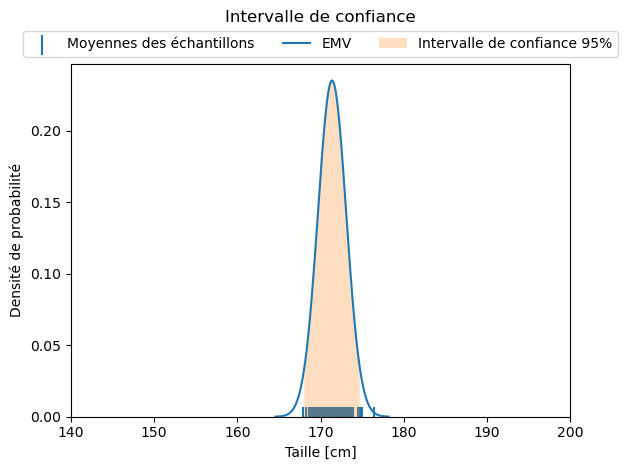

In [9]:
n = 30
m = 100
moyennes = calculer_moyennes(n, m)
tracer_intervalle(moyennes, option="confiance")

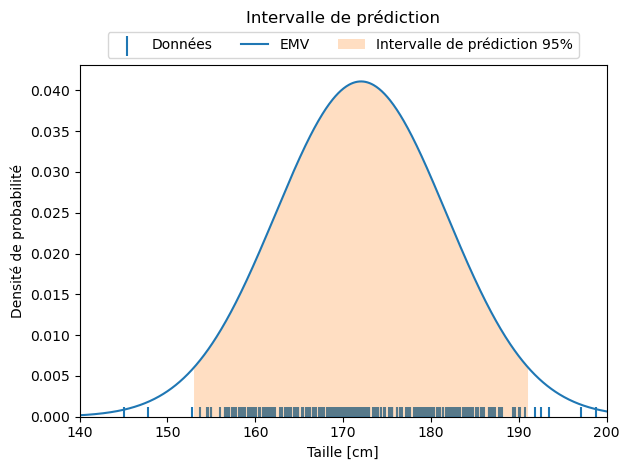

In [10]:
n = 300
tailles = generer_echantillon(n)
tracer_intervalle(tailles, option="prediction")

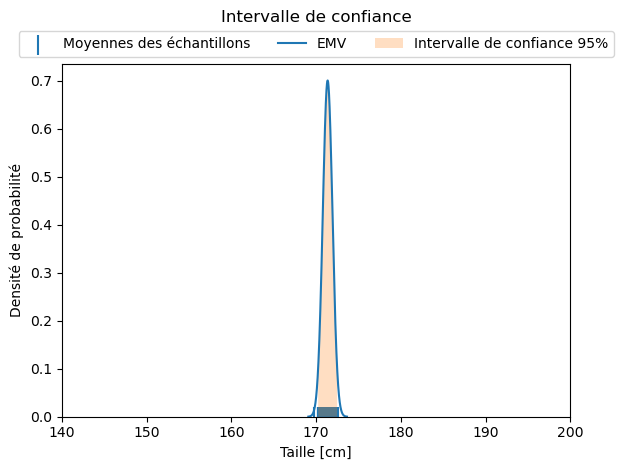

In [11]:
n = 300
m = 100
moyennes = calculer_moyennes(n, m)
tracer_intervalle(moyennes, option="confiance")

## Régression logistique

In [12]:
def phi(x):
    # Fonction d'augmentation pour un modèle purement linéaire
    return np.hstack((np.ones_like(x), x))

In [13]:
def logistic(z):
    # fonction logistique
    return 1 / (1 + np.exp(-z))

In [14]:
# Données des joueurs de rugby
X1 = np.array([175., 180., 193., 185., 186., 185., 177., 182., 181., 184., 184., 203., 200., 205., 197., 203., 203., 195., 199., 
               190., 191., 194., 190., 192., 174., 169., 182., 177., 175., 184., 186., 185., 190., 190., 184., 194., 192., 188., 
               183., 188., 184., 185., 182., 178.]).reshape(-1, 1)  # taille 
X2 = np.array([115., 119., 142., 112., 133., 124., 125., 107., 110., 109., 112., 142., 105., 133., 122., 138., 116., 108., 114., 
               111., 114., 108., 90., 107., 86., 82., 83., 83., 75., 86., 94., 89., 98., 100., 97., 94., 108., 102., 95., 97., 
               84., 84., 84., 87.]).reshape(-1, 1)  # poids
Y = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
              0, 0, 0, 0, 0, 0]).reshape(-1, 1)  # 1 avant, 0 trois-quart

In [15]:
# Utilisation de sklearn pour le problème de régression logistique
clf = LogisticRegression(C=np.inf, fit_intercept=False)
clf.fit(phi(X2), Y.ravel());

C:\ProgramData\miniforge3\envs\kmaxpp05\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


In [16]:
# Estimation des beta
beta_hat = clf.coef_.reshape(-1, 1)
beta_hat

array([[-29.63544442],
       [  0.28957248]])

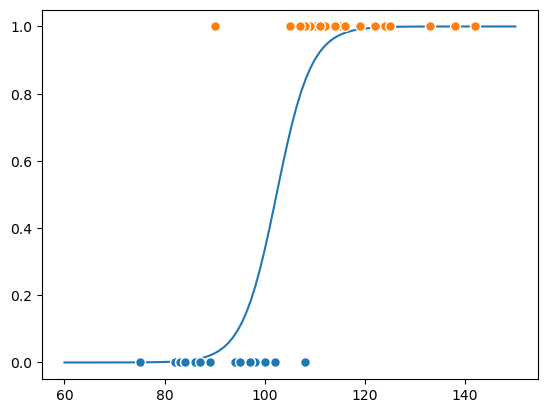

In [17]:
# Visualisation du modèle avec les données d'entrainement
xi = np.linspace(60., 150., 100).reshape(-1, 1)
plt.plot(xi, clf.predict_proba(phi(xi))[:,1])
mask = (Y == 0)
plt.scatter(X2[mask], Y[mask], edgecolor="w", s=50, zorder=10);
plt.scatter(X2[~mask], Y[~mask], edgecolor="w", s=50, zorder=10);

In [18]:
# Calcul de la matrice de covariance des estimations beta
p_hat = clf.predict_proba(phi(X2))[:,1]
W = np.eye(X2.shape[0]) * p_hat * (1 - p_hat)
cov_beta_hat = np.linalg.inv(phi(X2).T @ W @ phi(X2))

In [19]:
# Calcul de la variance du logit pour les données d'entrainement
cov_logit = phi(X2) @ cov_beta_hat @ phi(X2).T
var_logit = np.diagonal(cov_logit).reshape(-1, 1)

In [20]:
# Calcul de l'intervalle de confiance d'un niveau 1 - alpha
alpha = 0.05  # niveau de significativité
df = X2.shape[0] - beta_hat.shape[0]  # degrés de liberté du problème
coef = sp.stats.t(df).ppf([alpha/2.0, 1 - alpha/2.0])  # utilisation d'une loi de Student pour déterminer l'intervalle de confiance

In [21]:
# Calcul des intervalles sur le logit et la probabilité
IC_logit = phi(X2) @ beta_hat + coef * np.sqrt(var_logit)
IC_p_hat = logistic(IC_logit)

In [22]:
def espace_prediction(IC_p_hat, alpha):
    # Détermine l'espace de prédiction en fonction de l'intervalle de confiance et du niveau de significativité
    classes = []
    for p_hat_inf, p_hat_sup in IC_p_hat:
        if p_hat_sup <= alpha:
            classes.append((0,))
        elif p_hat_inf >= 1 - alpha:
            classes.append((1,))
        else:
            classes.append((0, 1))
    return classes

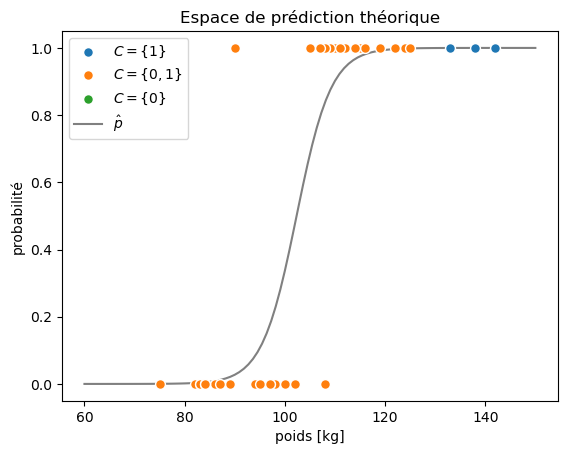

In [23]:
# Visualisation des espaces de prédictions pour les données d'apprentissage
espaces = espace_prediction(IC_p_hat, alpha)
mask = [True if c == (1,) else False for c in espaces]
plt.scatter(X2[mask], Y[mask], edgecolor="w", s=50, zorder=10, label=r"$C = \{1\}$");
mask = [True if c == (0,1) else False for c in espaces]
plt.scatter(X2[mask], Y[mask], edgecolor="w", s=50, zorder=10, label=r"$C = \{0,1\}$");
mask = [True if c == (0,) else False for c in espaces]
plt.scatter(X2[mask], Y[mask], edgecolor="w", s=50, zorder=10, label=r"$C = \{0\}$");
plt.plot(xi, logistic(phi(xi) @ beta_hat), color="grey", label=r"$\hat{p}$")
plt.legend();
plt.xlabel("poids [kg]")
plt.ylabel("probabilité")
plt.title("Espace de prédiction théorique")
plt.legend();

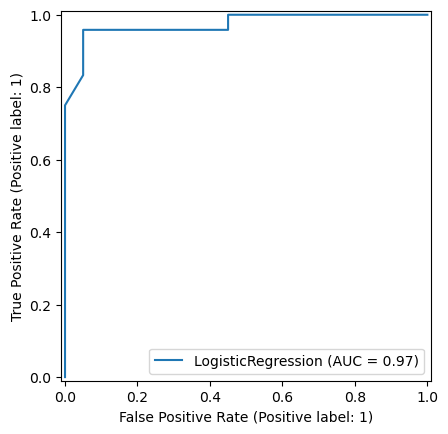

In [24]:
# Courbe ROC du problème de classification
RocCurveDisplay.from_estimator(clf, phi(X2), Y);

In [25]:
# Calcul des intervalles de confiance pour des points d'inférence Xi
xi = np.linspace(60., 150., 100).reshape(-1, 1)
cov_logit = phi(xi) @ cov_beta_hat @ phi(xi).T
var_logit = np.diagonal(cov_logit).reshape(-1, 1)
IC_logit = phi(xi) @ beta_hat + coef * np.sqrt(var_logit)  # On reste sur une loi de Student par conservatisme et similarité avec la régression
IC_p_hat = logistic(IC_logit)

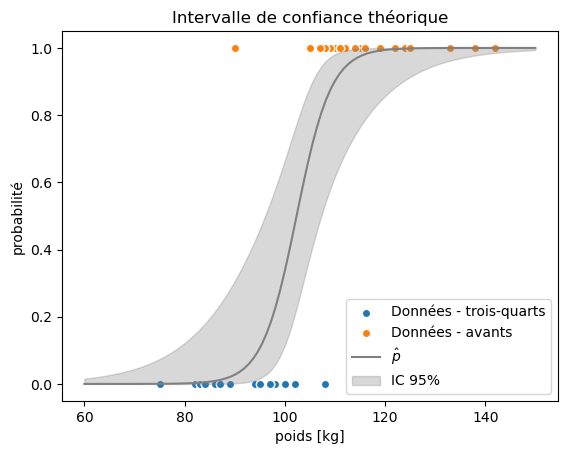

In [26]:
# Visualisation de l'intervalle de confiance théorique
mask = (Y == 0)
plt.scatter(X2[mask], Y[mask], edgecolor="w", label="Données - trois-quarts");
plt.scatter(X2[~mask], Y[~mask], edgecolor="w", label="Données - avants");
plt.plot(xi, logistic(phi(xi) @ beta_hat), color="grey", label=r"$\hat{p}$")
plt.fill_between(xi.ravel(), IC_p_hat[:,0], IC_p_hat[:,1], alpha=0.30, color="grey", label="IC 95%");
plt.xlabel("poids [kg]")
plt.ylabel("probabilité")
plt.title("Intervalle de confiance théorique")
plt.legend();

In [27]:
# Algorithme du bootstrapping pour le calcul des estimations beta
num_bootstraps = 1000
n = X2.shape[0]
indices = np.array(range(n))
beta_hat_arr = []
for i in range(num_bootstraps):
    bootstrap = np.random.choice(indices, n, replace=True)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clf = LogisticRegression(C=np.inf, fit_intercept=False)
        clf.fit(phi(X2[bootstrap]), Y[bootstrap].ravel())
        beta_hat = clf.coef_.reshape(-1, 1)
    beta_hat_arr.append(beta_hat)
beta_hat_arr = np.array(beta_hat_arr)

In [28]:
# Calcul des probabilités pour tous les bootstraps
p_hat_arr = []
for i in range(num_bootstraps):
    beta_hat = beta_hat_arr[i]
    p_hat_arr.append(logistic(phi(xi) @ beta_hat))
p_hat_arr = np.array(p_hat_arr)

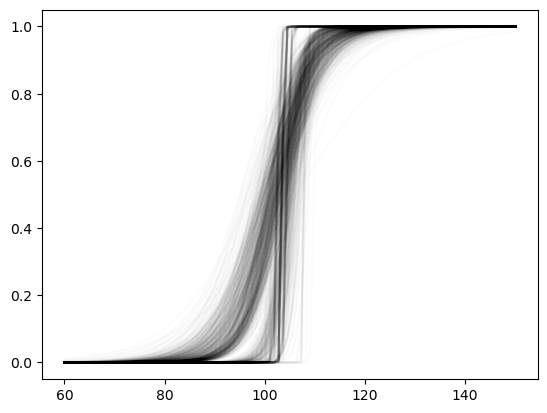

In [29]:
# Visualisation de touts les modèles entrainés
for i in range(num_bootstraps):
    plt.plot(xi, p_hat_arr[i], color="k", alpha=0.01)

In [30]:
# Déterminatation de l'intervalle de confiance sur la probabilité par la méthode des quantiles
IC_p_hat = np.quantile(p_hat_arr, [alpha/2.0, 1-alpha/2.0], axis=0)

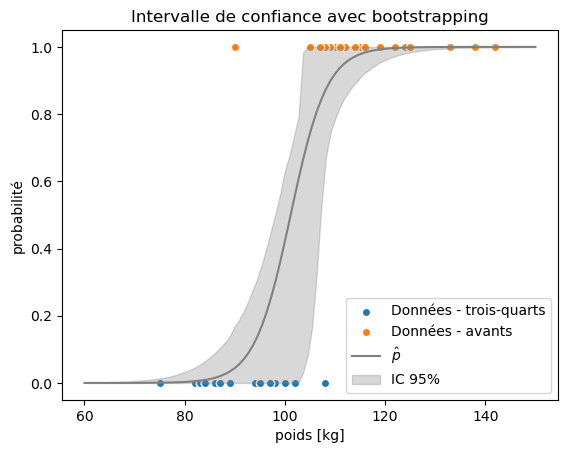

In [31]:
# Visualisation de l'intervalle de confiance par la méthode du bootstrapping
plt.scatter(X2[mask], Y[mask], edgecolor="w", label="Données - trois-quarts");
plt.scatter(X2[~mask], Y[~mask], edgecolor="w", label="Données - avants");
plt.plot(xi, logistic(phi(xi) @ beta_hat), color="grey", label=r"$\hat{p}$")
plt.fill_between(xi.ravel(), IC_p_hat[0].ravel(), IC_p_hat[1].ravel(), alpha=0.30, color="grey", label="IC 95%");
plt.xlabel("poids [kg]")
plt.ylabel("probabilité")
plt.title("Intervalle de confiance avec bootstrapping")
plt.legend();

## Régression linéaire

In [32]:
def moindres_carres(X_tilde, Y):
    # Resolution de la méthode des moindres carrés grâce à une décomposition QR
    # R @ beta = Q.T @ Y
    Q, R = np.linalg.qr(X_tilde)
    beta_hat = sp.linalg.solve_triangular(R, Q.T @ Y, lower=False)
    # Calculs des résidus
    res = Y - X_tilde @ beta_hat
    # Estimatation de sigma_epsilon**2
    n, p = X_tilde.shape
    s2 = np.sum(res**2) / (n - p)
    # Calcul de la matrice de covariance de beta hat
    R_inv = sp.linalg.solve_triangular(R, np.eye(R.shape[0]))
    cov_beta_hat = s2 * R_inv @ R_inv.T
    return beta_hat, cov_beta_hat, res, s2

In [33]:
# Estimation des beta et de la matrice de covariance ainsi que des résidus
beta_hat_full, cov_beta_hat, res, s2 = moindres_carres(phi(X1), X2)

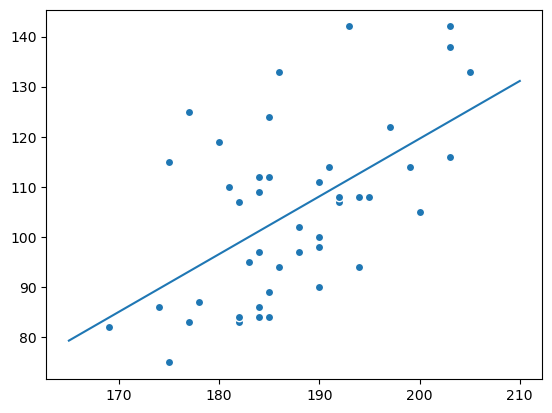

In [34]:
# Visualisation du modèle et des données d'apprentissage
xi = np.linspace(165, 210, 100).reshape(-1, 1)
y_hat = phi(xi) @ beta_hat_full
plt.scatter(X1, X2, edgecolor="w")
plt.plot(xi, y_hat);

In [35]:
# Estimation de la variance des estimations y sur des points d'inférence
xi = np.linspace(165, 210, 100).reshape(-1, 1)
var_y_hat = np.diagonal(phi(xi) @ cov_beta_hat @ phi(xi).T).reshape(-1, 1)

In [36]:
# Détermination des intervalles de confiance et prédiction d'un niveau 1 - alpha
alpha = 0.05  # seuil de significativité
df = X1.shape[0] - beta_hat_full.shape[0]   # degrés de liberté du problème
coef = sp.stats.t(df).ppf([alpha/2.0, 1 - alpha/2.0])  # utilisation d'une loi de Student
IC_y_hat = y_hat + coef * np.sqrt(var_y_hat)
IP_y_hat = y_hat + coef * np.sqrt(var_y_hat + s2)

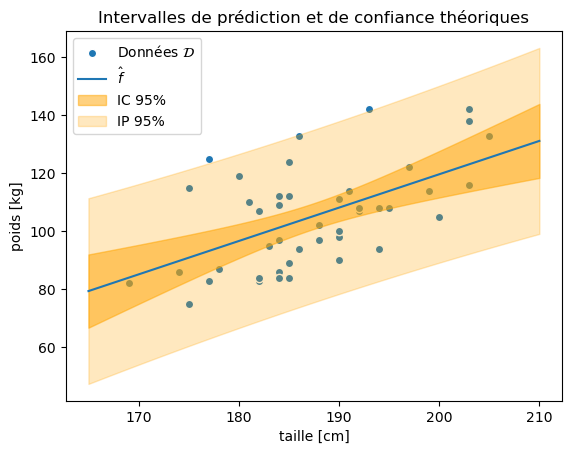

In [37]:
# Visualisation des intervalles théoriques
y_hat = phi(xi) @ beta_hat_full
plt.scatter(X1, X2, edgecolor="w", label=r"Données $\mathcal{D}$")
plt.plot(xi, y_hat, label=r"$\hat{f}$");
plt.fill_between(xi.ravel(), IC_y_hat[:,0], IC_y_hat[:,1], alpha=0.5, color="orange", label="IC 95%");
plt.fill_between(xi.ravel(), IP_y_hat[:,0], IP_y_hat[:,1], alpha=0.25, color="orange", label="IP 95%");
plt.xlabel("taille [cm]")
plt.ylabel("poids [kg]")
plt.title("Intervalles de prédiction et de confiance théoriques")
plt.legend();

In [38]:
# Algorithme du bootstrapping pour le calcul des estimations beta
num_bootstraps = 1000
n = X1.shape[0]
indices = np.array(range(n))
beta_hat_arr = []
for i in range(num_bootstraps):
    bootstrap = np.random.choice(indices, n, replace=True)
    beta_hat, _, _, _ = moindres_carres(phi(X1[bootstrap]), X2[bootstrap])
    beta_hat_arr.append(beta_hat)
beta_hat_arr = np.array(beta_hat_arr)

In [39]:
# Calcul des estimation y
y_hat_arr = []
for i in range(num_bootstraps):
    beta_hat = beta_hat_arr[i]
    y_hat_arr.append(phi(xi) @ beta_hat)
y_hat_arr = np.array(y_hat_arr).squeeze()

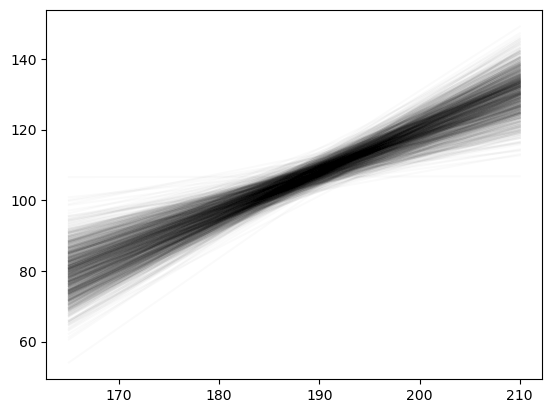

In [40]:
# Visualisation des modèles obtenus avec le bootstrapping
for i in range(num_bootstraps):
    plt.plot(xi, y_hat_arr[i], color="k", alpha=0.02)

In [41]:
# Détermination des intervalles par la méthode des quantiles
IC_y_hat = np.quantile(y_hat_arr, [alpha/2.0, 1-alpha/2.0], axis=0)
# Pour l'intervalle de prédiction on injecte du bruit aléatoire venant des résidus sur le modèle complet (un résidu par bootstrap)
IP_y_hat = np.quantile(y_hat_arr + np.random.choice(res.ravel(), (y_hat_arr.shape[0], 1)), [alpha/2.0, 1-alpha/2.0], axis=0)

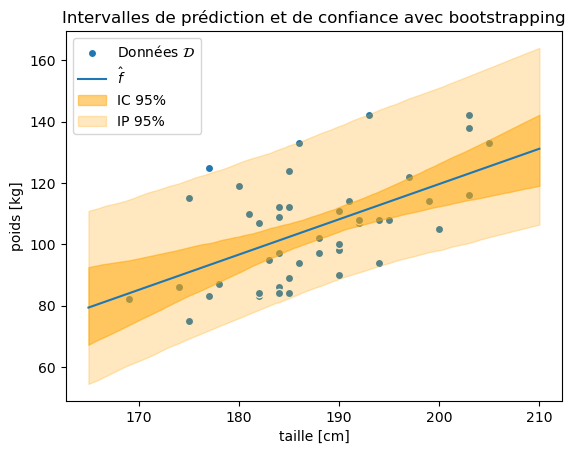

In [42]:
# Visualisation des intervalles par la méthode du bootstrapping
plt.scatter(X1, X2, edgecolor="w", label=r"Données $\mathcal{D}$")
plt.plot(xi, phi(xi) @ beta_hat_full, label=r"$\hat{f}$");
plt.fill_between(xi.ravel(), IC_y_hat[0].ravel(), IC_y_hat[1].ravel(), alpha=0.50, color="orange", label="IC 95%");
plt.fill_between(xi.ravel(), IP_y_hat[0].ravel(), IP_y_hat[1].ravel(), alpha=0.25, color="orange", label="IP 95%");
plt.xlabel("taille [cm]")
plt.ylabel("poids [kg]")
plt.title("Intervalles de prédiction et de confiance avec bootstrapping")
plt.legend();